# General report and analysis of model performance after training

### SLEAP Model Details

**Name**  
`abcEphysPilot01-cardModel`

**Type**  
`Multi-animal top-down (Centroid + Centered Instance)`

**Project folder**  
`/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card`

**Training data**  
`/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments`

**Training cameras**  
- `CameraEast`
- `CameraNest`
- `CameraNorth`
- `CameraTop`

**Held-out cameras**  
- `CameraSouth`
- `CameraWest`
- `CameraPatch2`
- `CameraPatch3`
- `CameraPatch4`
- `CameraPatch5`
- `CameraPatch6`

**Labels**  
`abcEphysPilot01_labels.v001.slp`

**Skeleton**  
`skeleton.json`

**Custom settings**  
- Anchor part: `corner_1`
- Centroid sigma: `5`
- Instance sigma: `2.5`
- Max instances: `1`

**Config path**  
`/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/model_config_files`

**Goal**  
Train on 4 cameras and test generalization to unseen views.

**After training**  
Model folder:  
`/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models`

- Centroid: `260416_103313.centroid.n=155`
- Centered instance: `260416_110846.centered_instance.n=155`
- Best checkpoint:
- Validation results:
- Inference settings:
- Failure cases:
- Next changes:


In [11]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis")
sys.path.append(str(PROJECT_ROOT / "scripts"))

import importlib
import sleap_notebook_report

importlib.reload(sleap_notebook_report)

from sleap_notebook_report import (
    load_model_pair,
    plot_learning_curves,
    plot_validation_scoreboard,
    plot_pixel_error,
    plot_part_accuracy,
    notebook_report_markdown,
)


In [12]:
models = load_model_pair(
    Path("/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/260416_103313.centroid.n=155"),
    Path("/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/260416_110846.centered_instance.n=155"),
)


## Model Report

This report summarizes the saved validation metrics for the models loaded in this notebook.

### General guide

- For metrics like `mOKS`, `mPCK`, `PCK@5`, visibility precision, and visibility recall:
  values **near 1** are better, and values **near 0** are worse.
- For metrics like average pixel error and validation loss:
  **lower is better**.
- These metrics should always be interpreted together, not one at a time.

### Metric meaning

- `mOKS`: overall keypoint agreement. Near `1` is very good.
- `mPCK`: fraction of keypoints placed close enough to the true location. Near `1` is very good.
- `PCK@5`: fraction of keypoints within 5 pixels of the true point. Higher is better.
- `Visibility precision`: when the model predicts a point is visible, how often that is correct.
- `Visibility recall`: when a point is truly visible, how often the model finds it.
- `Average pixel error`: average distance between prediction and label in pixels. Lower is better.
- `Best val loss`: the lowest validation loss reached during training. Lower is better.

### Metric table

| Model | mOKS | mPCK | PCK@5 | Vis. precision | Vis. recall | Avg error (px) | Best val loss |
|---|---:|---:|---:|---:|---:|---:|---:|
| centroid | 1.000 | 0.917 | 0.917 | 1.000 | 1.000 | 0.000 | 0.000059 |
| instance | 0.511 | 0.652 | 0.767 | 0.962 | 0.962 | 3.742 | 0.000097 |

### Notes

- Very high validation scores on a very small validation set can still be misleading.
- If inference on new videos looks poor, compare these scores with the actual rendered predictions.
- A strong centroid model with a weaker centered-instance model often means detection is good but corner placement still needs improvement.

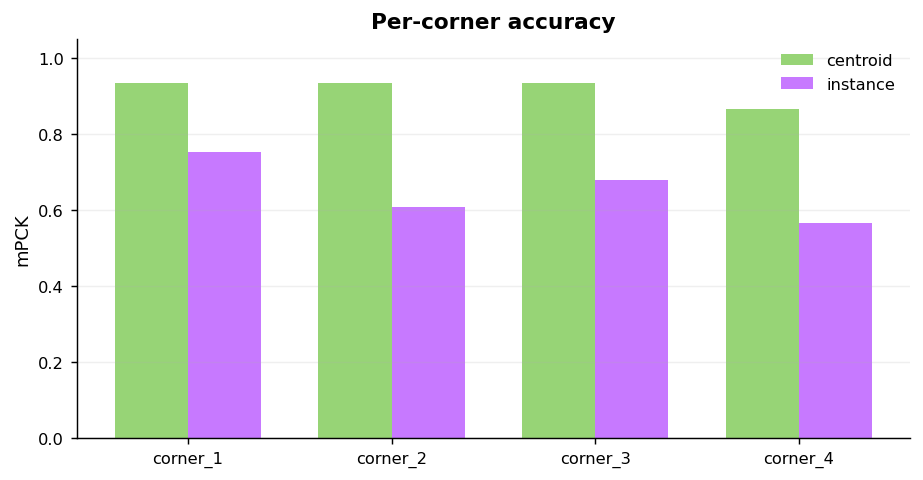

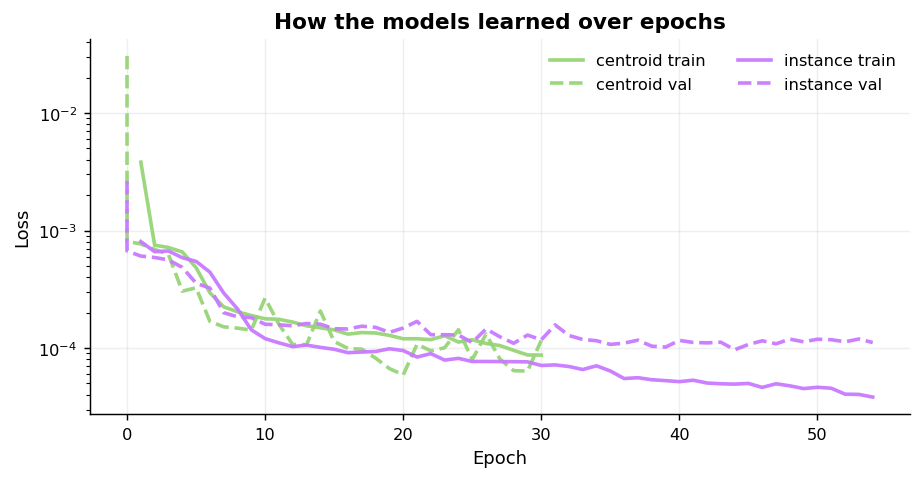

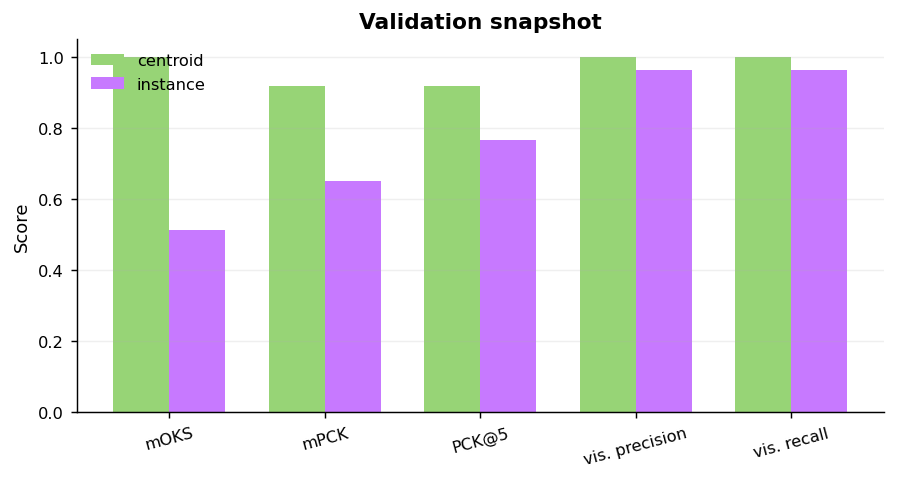

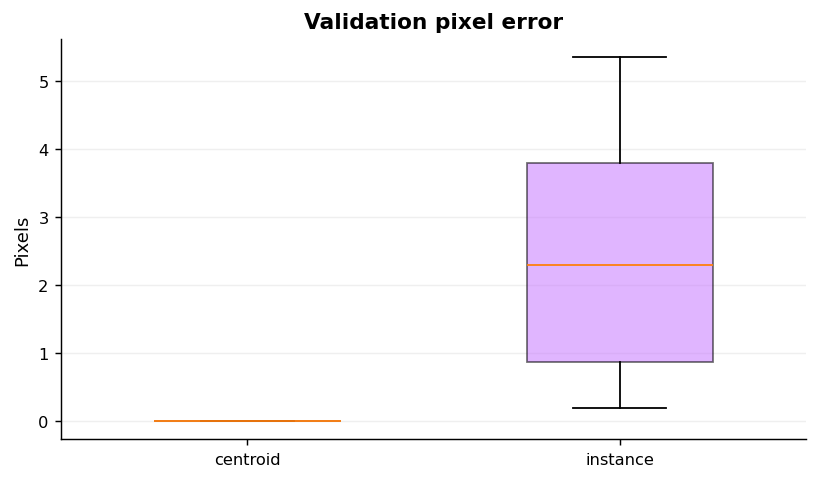

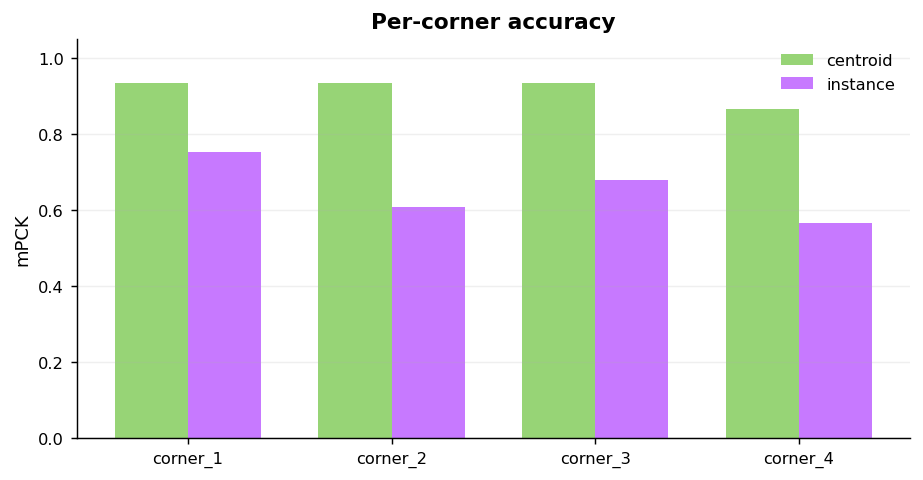

In [13]:
from IPython.display import Markdown, display

display(Markdown(notebook_report_markdown(models)))
plot_learning_curves(models)
plot_validation_scoreboard(models)
plot_pixel_error(models)
plot_part_accuracy(models)
